In [1]:
from itertools import product
import os
import sys
from pathlib import Path

PROJECT_ROOT1 = Path("/home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5")
PROJECT_ROOT2 = Path("/media")
sys.path.insert(0, str(PROJECT_ROOT1))
sys.path.insert(0, str(PROJECT_ROOT2))

# ---------------------------------------------------------------------
# TMPDIR for multiprocessing / tempfile
# ---------------------------------------------------------------------
import tempfile

TMP_DIR = Path("/media/general_storage6/rmastorage/tmp_aux2")
TMP_DIR.mkdir(parents=True, exist_ok=True)

os.environ["TMPDIR"] = str(TMP_DIR)
os.environ["TEMP"] = str(TMP_DIR)
os.environ["TMP"] = str(TMP_DIR)

tempfile.tempdir = str(TMP_DIR)

import glob
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    average_precision_score,
    auc,
    precision_recall_curve,
    roc_curve,
)
from tensorboard.backend.event_processing import event_accumulator
from torch.utils.data import DataLoader
from tqdm import tqdm

from models.doc_forgery_dataset_ela_rtm import DocForgeryELADataset   # change
from models.segformer_b2_rgb_ela_rtm.model_segformer_b2_rgb_ela_rtm import SegFormerRGBELARunner    # change
from models.torchtools.torch_collate_segformer_b2_rgb_ela_rtm import pad_collate    # change

/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/iss

In [38]:
# =============================================================================
# Configuration
# =============================================================================

EXP_NAME = "VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm"  # change
EXP_NAME_TRAIN = "TRAIN/All epochs/segformer_b2_rgb_ela_rtm/training_metric_plots"    # change

CKPT = (
    PROJECT_ROOT1
    #/ "models"
    #/ "weights_segformer_b2_rtm_several_inputs"
    #/ "generalstorage5" 
    / "weights_segformer_b2_rgb_ela_rtm_corretoo"
    / "segformer_b2-rgb-ela-q3_90"
    / "2026-05-18 07:14:35.577932-checkpoint16.pth"
)  # change

VAL_IMG_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/val_v2/JPEGImages"
VAL_MASK_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/val_v2/SegmentationClass"

TEST_IMG_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/test_v2/JPEGImages"
TEST_MASK_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/test_v2/SegmentationClass"

RUN_DIR = (
    PROJECT_ROOT1
    #/ "models"
    / "runs_segformer_b2_rgb_ela_rtm_corretoo"
    / "segformer_b2-rgb-ela-q3_90"
)  # change

BATCH_SIZE = 8
NUM_WORKERS = 0

MIN_QF2 = 97
MAX_QF2 = 100
QF3 = 90

TARGET_FPR_GOOD = 0.05

# 0-19 epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 0
#EPOCH_MAX = 20

# 20-49 epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 20
#EPOCH_MAX = 50

# 50-99 epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 50
#EPOCH_MAX = 52

# All epochs
EPOCH_OFFSET = 0
EPOCH_MIN = 0
EPOCH_MAX = 50

DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [39]:
# =============================================================================
# Output folders
# =============================================================================

OUT_ROOT = (
    PROJECT_ROOT1
    / "models"
    / "eval_outputs_corretoo"
    / EXP_NAME
)  # change
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DIR_MASKS = OUT_ROOT / "pred_masks"
DIR_PLOTS = OUT_ROOT / "plots"
DIR_TABLE = OUT_ROOT / "tables"
DIR_CMS   = OUT_ROOT / "confusion_matrices"

for folder in [DIR_MASKS, DIR_PLOTS, DIR_TABLE, DIR_CMS]:
    folder.mkdir(parents=True, exist_ok=True)

print("OUT_ROOT:", OUT_ROOT)

OUT_ROOT: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm


In [4]:
# =============================================================================
# Load checkpoint
# =============================================================================

ckpt = torch.load(CKPT, map_location="cpu")
THR = float(ckpt.get("best_thr", 0.5))

print(f"[TEST] Using pixel threshold = {THR:.4f}")

[TEST] Using pixel threshold = 0.0151


In [5]:
# =============================================================================
# Dataset and dataloader creation
# =============================================================================

def build_dataset(image_dir: str, mask_dir: str) -> DocForgeryELADataset:
    """Create a dataset with the same preprocessing used during evaluation."""
    
    dataset = DocForgeryELADataset(
        images_repo=[Path(image_dir)],
        masks_repo=[Path(mask_dir)],
        crop_size=(512, 512),
        grid_crop=True,
        #min_quality_factor=MIN_QF2,
        #max_quality_factor=MAX_QF2,
        #quality_factor=None,
        seed=3,
        balance_crops=False,
        stride=512,
        use_augs=False,
        verbose_stats=True,
    )

    dataset.use_augs = False
    dataset.QF = QF3
    return dataset


def build_loader(dataset: DocForgeryELADataset) -> DataLoader:
    """Create a dataloader with the custom padding collate function."""
    
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=lambda batch: pad_collate(batch, ignore_index=-1),
    )


ds_val = build_dataset(VAL_IMG_DIR, VAL_MASK_DIR)
ds_test = build_dataset(TEST_IMG_DIR, TEST_MASK_DIR)

dl_val = build_loader(ds_val)
dl_test = build_loader(ds_test)

print("VAL windows:", len(ds_val))
print("TEST windows:", len(ds_test))

[INFO] docs=900 windows=7033 pos=1771 neg=5262 balance_crops=False p_pos_crop=0.5 stride=512
[INFO] docs=900 windows=7120 pos=1743 neg=5377 balance_crops=False p_pos_crop=0.5 stride=512
VAL windows: 7033
TEST windows: 7120


In [6]:
# =============================================================================
# Load model
# =============================================================================

runner = SegFormerRGBELARunner(load_path=CKPT)   # change

runner.model.to(DEVICE)
runner.model.eval()

print("Model loaded on:", DEVICE)

=== HF DEBUG ===
cwd: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/scripts/RTM
HOME: /home/guests3/rma
HF_HOME: None
TRANSFORMERS_CACHE: None
HF_HUB_CACHE (const): /home/guests3/rma/.cache/huggingface/hub
HF_HUB_OFFLINE: None
TRANSFORMERS_OFFLINE: None
cache exists? True


Fetching 6 files: 100%|████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 31815.20it/s]
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at /home/guests3/rma/.cache/hf_models/models--nvidia--mit-b2/snapshots/3bb39e8739149c3777d0325349b2a6c32c6413db and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_hea

[SegFormer] num_labels: 1
[SegFormer] classifier weight: (1, 768, 1, 1)
... Loading weights
Done.
Model loaded on: cuda:1


In [7]:
# =============================================================================
# Basic metric helpers
# =============================================================================

TAMP_PREFIXES = {"cpmv", "insert", "splice", "edit", "inpaint", "cover"}
GOOD_PREFIXES = {"good"}


def group_from_stem(stem: str) -> str:
    """Map each image filename to its evaluation group."""
    
    prefix = stem.split("_")[0]

    if prefix in TAMP_PREFIXES:
        return "tamp"

    if prefix in GOOD_PREFIXES:
        return "good"


def new_cm() -> dict:
    """Initializes an empty binary confusion matrix with TP, FP, FN, and TN counters."""
    
    return {"tp": 0, "fp": 0, "fn": 0, "tn": 0}


def new_split_cms() -> dict:
    """Creates one confusion matrix for each evaluation split: tampered, good, and all."""
    
    return {split: new_cm() for split in ["tamp", "good", "all"]}


def update_binary_cm(cm: dict, pred_positive: bool, gt_positive: bool) -> None:
    """Updates a binary confusion matrix using one predicted label and one ground-truth label."""
    
    if gt_positive and pred_positive:
        cm["tp"] += 1
    elif not gt_positive and pred_positive:
        cm["fp"] += 1
    elif gt_positive and not pred_positive:
        cm["fn"] += 1
    else:
        cm["tn"] += 1


def update_image_cms(cms: dict, group: str, pred_positive: bool, gt_positive: bool) -> None:
    """Update group, global, and aggregate tampered/good image-level CMs."""
    
    update_binary_cm(cms[group], pred_positive, gt_positive)
    update_binary_cm(cms["all"], pred_positive, gt_positive)

    aggregate = "good" if group == "good" else "tamp"
    if group != aggregate:
        update_binary_cm(cms[aggregate], pred_positive, gt_positive)


def update_pixel_cm(cm: dict, pred01: np.ndarray, gt: np.ndarray, ignore: int = -1) -> None:
    """Updates the pixel-level confusion matrix by comparing the predicted binary mask with the ground-truth mask while ignoring invalid pixels."""
    
    valid = gt != ignore

    if valid.sum() == 0:
        return

    pred = pred01[valid].astype(np.uint8)
    target = gt[valid].astype(np.uint8)

    cm["tp"] += int(((pred == 1) & (target == 1)).sum())
    cm["fp"] += int(((pred == 1) & (target == 0)).sum())
    cm["fn"] += int(((pred == 0) & (target == 1)).sum())
    cm["tn"] += int(((pred == 0) & (target == 0)).sum())


def update_pixel_cms(cms: dict, group: str, pred01: np.ndarray, gt: np.ndarray) -> None:
    """Update group, global, and aggregate tampered/good pixel-level CMs."""
    
    update_pixel_cm(cms[group], pred01, gt)
    update_pixel_cm(cms["all"], pred01, gt)

    aggregate = "good" if group == "good" else "tamp"
    if group != aggregate:
        update_pixel_cm(cms[aggregate], pred01, gt)


def pix_metrics(cm: dict, eps: float = 1e-6) -> tuple:
    """Computes pixel-level IoU, precision, recall, F1-score, and accuracy from a pixel-level confusion matrix."""
    
    tp, fp, fn, tn = cm["tp"], cm["fp"], cm["fn"], cm["tn"]

    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = (2 * tp) / (2 * tp + fp + fn + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)

    return iou, precision, recall, f1, acc


def img_metrics(cm: dict, eps: float = 1e-12) -> tuple:
    """Computes image-level precision, recall, F1-score, accuracy, false positive rate, and specificity from an image-level confusion matrix."""
    
    tp, fp, fn, tn = cm["tp"], cm["fp"], cm["fn"], cm["tn"]

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = (2 * precision * recall) / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    fpr = fp / (fp + tn + eps)
    specificity = tn / (tn + fp + eps)

    return (
        float(precision),
        float(recall),
        float(f1),
        float(acc),
        float(fpr),
        float(specificity),
    )


def metrics_at_tau(y_true, y_score, tau: float) -> dict:
    """Compute image-level metrics for the rule score >= tau."""
    
    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)
    pred = (y_score >= tau).astype(np.int64)

    cm = {
        "tp": int(((pred == 1) & (y_true == 1)).sum()),
        "fp": int(((pred == 1) & (y_true == 0)).sum()),
        "fn": int(((pred == 0) & (y_true == 1)).sum()),
        "tn": int(((pred == 0) & (y_true == 0)).sum()),
    }

    precision, recall, f1, acc, fpr, specificity = img_metrics(cm)

    return {
        "tau": float(tau),
        "P": precision,
        "R": recall,
        "F1": f1,
        "Acc": acc,
        "FPR": fpr,
        "Specificity": specificity,
        "TP": cm["tp"],
        "FP": cm["fp"],
        "FN": cm["fn"],
        "TN": cm["tn"],
    }


def cm_to_array(cm: dict) -> np.ndarray:
    """Converts a confusion matrix dictionary into a 2x2 NumPy array for visualization."""
    
    return np.array(
        [[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]],
        dtype=np.int64,
    )

In [8]:
# =============================================================================
# Plot helpers
# =============================================================================

def save_cm_png(cm_arr: np.ndarray, title: str, out_path: Path) -> None:
    """Saves a confusion matrix as a PNG image."""
    
    out_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure()
    plt.imshow(cm_arr)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("GT")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for (i, j), value in np.ndenumerate(cm_arr):
        plt.text(j, i, str(value), ha="center", va="center", color="white")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_roc_pr_curves(y_true, y_score, out_dir: Path, prefix: str = "image_area") -> dict:
    """Saves ROC and precision-recall curves and returns AUC-based metrics for the image-level scores."""
    
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR (Recall)")
    plt.title(f"ROC ({prefix}) AUC={roc_auc:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / f"{prefix}_roc.png", dpi=200)
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR ({prefix}) AP={pr_auc:.4f}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / f"{prefix}_pr.png", dpi=200)
    plt.close()

    def recall_at_fpr(target_fpr: float) -> float:
        idx = np.searchsorted(fpr, target_fpr, side="right") - 1
        idx = np.clip(idx, 0, len(tpr) - 1)
        return float(tpr[idx])

    return {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "recall@fpr=1%": recall_at_fpr(0.01),
        "recall@fpr=5%": recall_at_fpr(0.05),
        "recall@fpr=10%": recall_at_fpr(0.10),
    }


def pr_curve_numpy(y_true, y_score):
    """Compute a simple precision-recall curve using NumPy."""
    
    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float64)

    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]
    y_score_sorted = y_score[order]

    positives = y_true_sorted.sum()

    if positives == 0:
        return np.array([1.0]), np.array([0.0]), np.array([np.inf])

    tp = np.cumsum(y_true_sorted == 1)
    fp = np.cumsum(y_true_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1e-12)
    recall = tp / np.maximum(positives, 1e-12)
    thresholds = y_score_sorted.copy()

    # Add the initial PR point at recall = 0.
    precision = np.concatenate([[1.0], precision])
    recall = np.concatenate([[0.0], recall])
    thresholds = np.concatenate([[thresholds[0] + 1e-12], thresholds])

    return precision, recall, thresholds


def pr_auc_trapz(precision, recall) -> float:
    """Computes the area under the precision-recall curve using trapezoidal integration."""
    
    order = np.argsort(recall)
    return float(np.trapz(precision[order], recall[order]))


def save_val_pr_curve_with_tau(y_true, y_score, tau: float, out_path: Path) -> dict:
    """Saves the validation precision-recall curve and marks the selected operating threshold on the plot."""
    
    precision, recall, _ = pr_curve_numpy(y_true, y_score)
    pr_auc = pr_auc_trapz(precision, recall)

    metrics = metrics_at_tau(y_true, y_score, tau)
    p_tau = metrics["P"]
    r_tau = metrics["R"]

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure()
    plt.plot(recall, precision, linewidth=2)
    plt.scatter([r_tau], [p_tau], s=80, marker="o")
    plt.title(f"VAL PR curve (PR-AUC≈{pr_auc:.4f}) | tau={tau:.6f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

    return {
        "pr_auc": pr_auc,
        "p_tau": p_tau,
        "r_tau": r_tau,
        "tau": float(tau),
    }

In [9]:
# =============================================================================
# Inference with crop stitching
# =============================================================================

def topk_mean(prob_map: np.ndarray, valid_mask: np.ndarray, frac: float, min_k: int) -> float:
    """Compute the average probability over the top-k valid pixels."""
    
    vals = prob_map[valid_mask].reshape(-1)
    n = vals.size

    if n == 0:
        return 0.0

    k = min(int(max(min_k, round(frac * n))), n)

    if k == n:
        return float(vals.mean())

    topk = np.partition(vals, n - k)[n - k:]
    return float(topk.mean())


def load_hw_for_doc(dataset: DocForgeryELADataset, doc_i: int) -> tuple:
    """Reads the original image size of a document so that crop predictions can be stitched back into a full-resolution mask."""
    
    img_path = dataset.images[doc_i]
    image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"Could not read image: {img_path}")

    return image.shape[:2]


def infer_stitch_save_and_cm(
    runner,
    dl,
    ds,
    device,
    thr_pix: float = 0.5,
    tau_area: float = 0.001,
    topk_frac: float = 0.001,
    topk_min_k: int = 50,
    pred_masks_dir=None,
    save_masks: bool = True,
) -> dict:
    """Runs inference on all crops, stitches crop predictions into full-document masks, saves masks, and collects pixel-level and image-level metrics."""
    
    pix_cm = new_split_cms()
    img_cm_any = new_split_cms()
    img_cm_area = new_split_cms()

    cur_doc_i = None
    cur_stem = None
    cur_group = None

    acc_sum = None
    acc_cnt = None
    gt_full = None
    height = width = None

    img_scores = []
    img_labels = []
    stems_out = []

    # These cached arrays allow grid-search without running inference again.
    img_vals_sorted = []
    img_nvalid = []

    def flush_current() -> None:
        nonlocal cur_doc_i, cur_stem, cur_group
        nonlocal acc_sum, acc_cnt, gt_full, height, width

        if cur_doc_i is None:
            return

        prob = acc_sum / np.maximum(acc_cnt, 1.0)
        pred01 = (prob >= thr_pix).astype(np.uint8)

        valid = gt_full != -1
        gt_has = bool(((gt_full == 1) & valid).any())

        vals = prob[valid].reshape(-1).astype(np.float32)
        img_vals_sorted.append(np.sort(vals)[::-1])
        img_nvalid.append(int(vals.size))

        pred_any = bool(((pred01 == 1) & valid).any())
        score_topk = topk_mean(prob, valid, frac=topk_frac, min_k=topk_min_k)
        pred_topk = bool(score_topk >= tau_area)

        update_pixel_cms(pix_cm, cur_group, pred01, gt_full)
        update_image_cms(img_cm_any, cur_group, pred_any, gt_has)
        update_image_cms(img_cm_area, cur_group, pred_topk, gt_has)

        img_scores.append(score_topk)
        img_labels.append(1 if gt_has else 0)
        stems_out.append(cur_stem)

        if save_masks and pred_masks_dir is not None:
            output_dir = Path(pred_masks_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(output_dir / f"{cur_stem}.png"), pred01 * 255)

    runner.model.eval()

    with torch.no_grad():
        for batch in tqdm(dl, total=len(dl), desc="Infer+stitch"):
            out = runner.logits(batch, device=device, loss_fn=None)

            probs = torch.sigmoid(out.logits).squeeze(1).cpu().numpy()
            masks = out.labels.squeeze(1).cpu().numpy().astype(np.int16)

            metas = batch["meta"]
            stems = [meta["stem"] for meta in metas]
            doc_ids = [int(meta["doc_i"]) for meta in metas]
            origins = [meta["origin"] for meta in metas]

            for i, stem in enumerate(stems):
                doc_i = doc_ids[i]
                y, x = origins[i]

                if cur_doc_i is None or doc_i != cur_doc_i:
                    flush_current()

                    cur_doc_i = doc_i
                    cur_stem = stem
                    cur_group = group_from_stem(stem)

                    height, width = load_hw_for_doc(ds, doc_i)
                    acc_sum = np.zeros((height, width), np.float32)
                    acc_cnt = np.zeros((height, width), np.float32)
                    gt_full = np.full((height, width), -1, np.int16)

                prob_crop = probs[i]
                gt_crop = masks[i]

                crop_h, crop_w = prob_crop.shape
                y2 = min(y + crop_h, height)
                x2 = min(x + crop_w, width)

                prob_crop = prob_crop[: y2 - y, : x2 - x]
                gt_crop = gt_crop[: y2 - y, : x2 - x]

                valid_crop = gt_crop != -1

                acc_sum[y:y2, x:x2][valid_crop] += prob_crop[valid_crop]
                acc_cnt[y:y2, x:x2][valid_crop] += 1.0
                gt_full[y:y2, x:x2][valid_crop] = gt_crop[valid_crop]

    flush_current()

    return {
        "pix_cm": pix_cm,
        "img_cm_any": img_cm_any,
        "img_cm_area": img_cm_area,
        "img_scores": np.asarray(img_scores, dtype=np.float32),
        "img_labels": np.asarray(img_labels, dtype=np.int64),
        "stems": stems_out,
        "img_vals_sorted": img_vals_sorted,
        "img_nvalid": np.asarray(img_nvalid, dtype=np.int32),
    }

In [10]:
# =============================================================================
# Validation inference for cached TOP-K scores
# =============================================================================

val_res_base = infer_stitch_save_and_cm(
    runner=runner,
    dl=dl_val,
    ds=ds_val,
    device=DEVICE,
    thr_pix=THR,
    tau_area=0.0,
    topk_frac=0.001,
    topk_min_k=50,
    pred_masks_dir=None,
    save_masks=False,
)

vals_sorted_list = val_res_base["img_vals_sorted"]
nvalid = val_res_base["img_nvalid"]
y_true = val_res_base["img_labels"]
stems = val_res_base["stems"]

is_good = np.array([group_from_stem(stem) == "good" for stem in stems], dtype=bool)

print("VAL images:", len(y_true))
print("VAL good images:", int(is_good.sum()))

Infer+stitch: 100%|███████████████████████████████████████████████████████████████████| 880/880 [24:29<00:00,  1.67s/it]

VAL images: 900
VAL good images: 300


In [11]:
# =============================================================================
# TOP-K grid-search helpers
# =============================================================================

def scores_for_combo(vals_sorted_list, nvalid, topk_frac: float, topk_min_k: int) -> np.ndarray:
    """Compute image-level scores from cached sorted probabilities."""
    
    y_score = np.zeros(len(vals_sorted_list), dtype=np.float32)

    for i, vals_sorted in enumerate(vals_sorted_list):
        n = int(nvalid[i])

        if n == 0:
            y_score[i] = 0.0
            continue

        k = min(int(max(topk_min_k, round(topk_frac * n))), n)
        y_score[i] = float(vals_sorted[:k].mean())

    return y_score


def pick_tau_by_fpr_good(
    y_score,
    y_true,
    is_good,
    target_fpr: float = 0.05,
    grid=None,
) -> dict:
    """Pick the smallest tau that satisfies FPR_good <= target_fpr."""
    
    y_score = np.asarray(y_score, dtype=np.float32)
    y_true = np.asarray(y_true, dtype=np.int64)
    is_good = np.asarray(is_good, dtype=bool)

    good_scores = y_score[is_good]

    if good_scores.size == 0:
        raise ValueError("No 'good' validation images available to calibrate FPR_good.")

    if grid is None:
        quantiles = np.unique(
            np.quantile(
                good_scores,
                [0.50, 0.70, 0.80, 0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999],
            )
        )
        linear = np.linspace(0.0, 1.0, 201, dtype=np.float32)
        grid = np.unique(np.clip(np.concatenate([linear, quantiles]), 0.0, 1.0)).astype(np.float32)

    best_stats = None

    for tau in np.sort(grid):
        stats = metrics_at_tau(y_true, y_score, tau)

        pred_good = (y_score[is_good] >= tau).astype(np.uint8)
        fp_good = int((pred_good == 1).sum())
        tn_good = int((pred_good == 0).sum())

        fpr_good = fp_good / max(fp_good + tn_good, 1)
        specificity_good = tn_good / max(fp_good + tn_good, 1)

        stats.update(
            {
                "FPR_good": float(fpr_good),
                "Specificity_good": float(specificity_good),
                "FP_good": fp_good,
                "TN_good": tn_good,
            }
        )

        best_stats = stats

        if fpr_good <= target_fpr:
            break

    return best_stats

In [12]:
def update_pix(cm, pred01, gt, ignore=-1):
    """Updates a pixel-level confusion matrix for one predicted mask and one ground-truth mask."""
    
    valid = (gt != ignore)
    if valid.sum() == 0:
        return
    p = pred01[valid].astype(np.uint8)
    g = gt[valid].astype(np.uint8)
    cm["tp"] += int(((p == 1) & (g == 1)).sum())
    cm["fp"] += int(((p == 1) & (g == 0)).sum())
    cm["fn"] += int(((p == 0) & (g == 1)).sum())
    cm["tn"] += int(((p == 0) & (g == 0)).sum())

def update_img_any(cm, pred01, gt, ignore=-1):
    """Updates an image-level confusion matrix using the rule that a document is positive if any pixel is predicted as manipulated."""
    
    valid = (gt != ignore)
    if valid.sum() == 0:
        return
    gt_has = bool(((gt == 1) & valid).any())
    pr_has = bool(((pred01 == 1) & valid).any())
    if gt_has and pr_has:
        cm["tp"] += 1
    elif (not gt_has) and pr_has:
        cm["fp"] += 1
    elif gt_has and (not pr_has):
        cm["fn"] += 1
    else:
        cm["tn"] += 1

def update_img_area(cm, pr_area_ratio, gt, tau_area, ignore=-1):
    """Updates an image-level confusion matrix using an aggregated area or TOP-K score threshold."""
    
    valid = (gt != ignore)
    if valid.sum() == 0:
        return
    gt_has = bool(((gt == 1) & valid).any())
    pr_has = bool(pr_area_ratio >= tau_area)
    if gt_has and pr_has:
        cm["tp"] += 1
    elif (not gt_has) and pr_has:
        cm["fp"] += 1
    elif gt_has and (not pr_has):
        cm["fn"] += 1
    else:
        cm["tn"] += 1

In [13]:
# =============================================================================
# TOP-K search space
# =============================================================================

TOPK_FRAC_GRID = sorted(
    set(
        list(np.logspace(np.log10(1e-4), np.log10(2e-2), 10))
        + [0.00025, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.01]
    )
)

TOPK_MIN_K_GRID = [5, 10, 25, 50, 75, 100, 150, 200, 300, 500]

combos = list(product(TOPK_FRAC_GRID, TOPK_MIN_K_GRID))
df_combos = pd.DataFrame(combos, columns=["topk_frac", "topk_min_k"])

df_combos.to_csv(DIR_TABLE / "tested_combos.csv", index=False, encoding="utf-8")

print("Num combos:", len(combos))
display(df_combos)

Num combos: 170


,topk_frac,topk_min_k
0,0.0001,5
1,0.0001,10
2,0.0001,25
3,0.0001,50
4,0.0001,75
...,...,...
165,0.0200,100
166,0.0200,150
167,0.0200,200
168,0.0200,300


In [14]:
# =============================================================================
# TOP-K grid search on validation
# =============================================================================

rows = []
t0 = time.time()

for i, (frac, kmin) in enumerate(combos, start=1):
    y_score = scores_for_combo(vals_sorted_list, nvalid, frac, kmin)

    best_fpr = pick_tau_by_fpr_good(
        y_score=y_score,
        y_true=y_true,
        is_good=is_good,
        target_fpr=TARGET_FPR_GOOD,
        grid=None,
    )

    tau = best_fpr["tau"]
    m_all = metrics_at_tau(y_true, y_score, tau)

    rows.append(
        {
            "topk_frac": float(frac),
            "topk_min_k": int(kmin),
            "tau_topk": float(tau),
            "P_all": float(m_all["P"]),
            "R_all": float(m_all["R"]),
            "F1_all": float(m_all["F1"]),
            "Acc_all": float(m_all["Acc"]),
            "TP": int(m_all["TP"]),
            "FP": int(m_all["FP"]),
            "FN": int(m_all["FN"]),
            "TN": int(m_all["TN"]),
            "FPR_good": float(best_fpr["FPR_good"]),
            "Specificity_good": float(best_fpr["Specificity_good"]),
            "FP_good": int(best_fpr["FP_good"]),
            "TN_good": int(best_fpr["TN_good"]),
            "target_fpr_good": float(TARGET_FPR_GOOD),
        }
    )

    if i % 10 == 0:
        print(
            f"[{i}/{len(combos)}] "
            f"frac={frac:.6f} "
            f"kmin={kmin} "
            f"F1_all={m_all['F1']:.4f} "
            f"FPR_good={best_fpr['FPR_good']:.4f} "
            f"tau={tau:.4f}"
        )

df_grid = pd.DataFrame(rows)
df_grid["ok_fpr"] = df_grid["FPR_good"] <= TARGET_FPR_GOOD

df_valid = df_grid[df_grid["ok_fpr"]].copy()

if df_valid.empty:
    print("No combo satisfies the FPR_good constraint. Selecting the lowest FPR_good.")
    best = df_grid.sort_values(["FPR_good", "F1_all"], ascending=[True, False]).iloc[0]
else:
    best = df_valid.sort_values(["F1_all", "FPR_good"], ascending=[False, True]).iloc[0]

path_grid = DIR_TABLE / "gridsearch_topk_val.csv"
df_grid.to_csv(path_grid, index=False, encoding="utf-8")

print("Grid done in seconds:", round(time.time() - t0, 1))
print("Saved grid CSV:", path_grid)

df_grid.head(15)

[10/170] frac=0.000100 kmin=500 F1_all=0.2471 FPR_good=0.0333 tau=1.0000
[20/170] frac=0.000180 kmin=500 F1_all=0.3534 FPR_good=0.0500 tau=1.0000
[30/170] frac=0.000250 kmin=500 F1_all=0.3534 FPR_good=0.0500 tau=1.0000
[40/170] frac=0.000325 kmin=500 F1_all=0.3534 FPR_good=0.0500 tau=1.0000
[50/170] frac=0.000500 kmin=500 F1_all=0.3534 FPR_good=0.0500 tau=1.0000
[60/170] frac=0.000585 kmin=500 F1_all=0.3556 FPR_good=0.0500 tau=1.0000
[70/170] frac=0.001000 kmin=500 F1_all=0.3773 FPR_good=0.0500 tau=1.0000
[80/170] frac=0.001054 kmin=500 F1_all=0.3730 FPR_good=0.0500 tau=1.0000
[90/170] frac=0.001898 kmin=500 F1_all=0.3752 FPR_good=0.0500 tau=0.9997
[100/170] frac=0.002000 kmin=500 F1_all=0.3858 FPR_good=0.0500 tau=0.9993
[110/170] frac=0.003000 kmin=500 F1_all=0.3665 FPR_good=0.0500 tau=0.9952
[120/170] frac=0.003420 kmin=500 F1_all=0.3644 FPR_good=0.0500 tau=0.9906
[130/170] frac=0.005000 kmin=500 F1_all=0.3752 FPR_good=0.0500 tau=0.8999
[140/170] frac=0.006162 kmin=500 F1_all=0.3709 

,topk_frac,topk_min_k,tau_topk,P_all,R_all,F1_all,Acc_all,TP,FP,FN,TN,FPR_good,Specificity_good,FP_good,TN_good,target_fpr_good,ok_fpr
0,0.00010,5,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
1,0.00010,10,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
2,0.00010,25,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
3,0.00010,50,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
4,0.00010,75,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
5,0.00010,100,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
6,0.00010,150,1.0,0.891089,0.150000,0.256776,0.421111,90,11,510,289,0.036667,0.963333,11,289,0.05,True
7,0.00010,200,1.0,0.890000,0.148333,0.254286,0.420000,89,11,511,289,0.036667,0.963333,11,289,0.05,True
8,0.00010,300,1.0,0.890000,0.148333,0.254286,0.420000,89,11,511,289,0.036667,0.963333,11,289,0.05,True
9,0.00010,500,1.0,0.895833,0.143333,0.247126,0.417778,86,10,514,290,0.033333,0.966667,10,290,0.05,True


In [15]:
# =============================================================================
# Grid-search heatmap table
# =============================================================================

pivot_f1 = (
    df_grid
    .pivot_table(index="topk_min_k", columns="topk_frac", values="F1_all", aggfunc="max")
    .sort_index()
)

pivot_f1

topk_frac,0.000100,0.000180,0.000250,0.000325,0.000500,0.000585,0.001000,0.001054,0.001898,0.002000,0.003000,0.003420,0.005000,0.006162,0.010000,0.011101,0.020000
topk_min_k,,,,,,,,,,,,,,,,,
5,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
10,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
25,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
50,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
75,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
100,0.256776,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
150,0.256776,0.254286,0.266667,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
200,0.254286,0.254286,0.269122,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781
300,0.254286,0.254286,0.254286,0.351206,0.357810,0.362184,0.377309,0.373016,0.375165,0.385827,0.366534,0.364362,0.375165,0.370861,0.379447,0.375165,0.35781


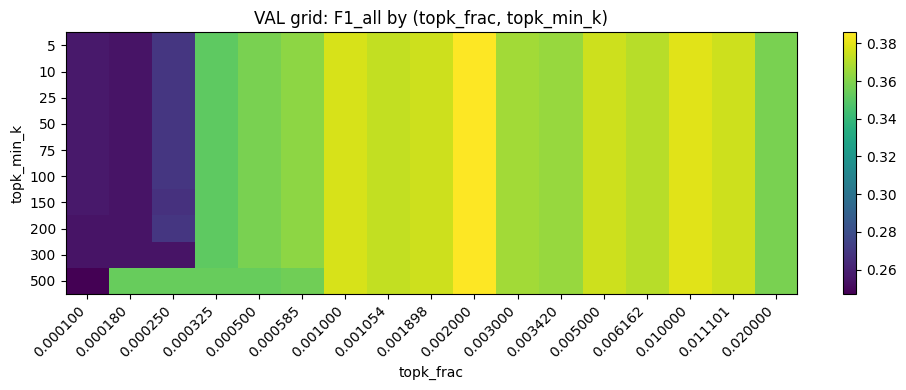

In [16]:
# =============================================================================
# Grid-search heatmap plot
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_f1.values, aspect="auto")

ax.set_xticks(range(pivot_f1.shape[1]))
ax.set_xticklabels([f"{c:.6f}" for c in pivot_f1.columns], rotation=45, ha="right")

ax.set_yticks(range(pivot_f1.shape[0]))
ax.set_yticklabels([str(i) for i in pivot_f1.index])

ax.set_xlabel("topk_frac")
ax.set_ylabel("topk_min_k")
ax.set_title("VAL grid: F1_all by (topk_frac, topk_min_k)")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

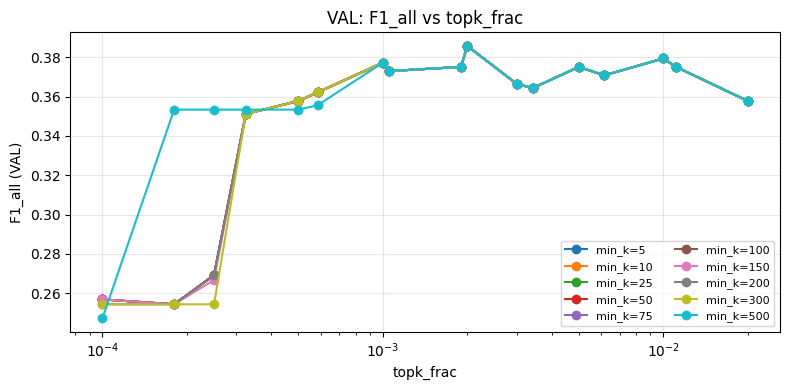

In [17]:
# =============================================================================
# F1 curves per topk_min_k
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 4))

for min_k in TOPK_MIN_K_GRID:
    subset = df_grid[df_grid["topk_min_k"] == min_k].sort_values("topk_frac")
    ax.plot(subset["topk_frac"], subset["F1_all"], marker="o", label=f"min_k={min_k}")

ax.set_xscale("log")
ax.set_xlabel("topk_frac")
ax.set_ylabel("F1_all (VAL)")
ax.set_title("VAL: F1_all vs topk_frac")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# Best TOP-K combination
# =============================================================================

BEST_TOPK_FRAC = float(best["topk_frac"])
BEST_TOPK_MIN_K = int(best["topk_min_k"])
BEST_TAU = float(best["tau_topk"])

print("=== BEST (VAL) ===")
print("TOPK_FRAC:", BEST_TOPK_FRAC)
print("TOPK_MIN_K:", BEST_TOPK_MIN_K)
print("TAU_TOPK:", BEST_TAU)
print("F1_all:", float(best["F1_all"]))
print("FPR_good:", float(best["FPR_good"]))

=== BEST (VAL) ===
TOPK_FRAC: 0.002
TOPK_MIN_K: 5
TAU_TOPK: 0.999321699142456
F1_all: 0.38582677165320745
FPR_good: 0.05


In [19]:
# =============================================================================
# Validation metrics with best TOP-K combination
# =============================================================================

y_score_val = scores_for_combo(vals_sorted_list, nvalid, BEST_TOPK_FRAC, BEST_TOPK_MIN_K)
m_all = metrics_at_tau(y_true, y_score_val, BEST_TAU)

print("VAL @best:", m_all)

VAL @best: {'tau': 0.999321699142456, 'P': 0.9074074074074019, 'R': 0.24499999999999958, 'F1': 0.38582677165320745, 'Acc': 0.4799999999999994, 'FPR': 0.04999999999999983, 'Specificity': 0.9499999999999967, 'TP': 147, 'FP': 15, 'FN': 453, 'TN': 285}


In [20]:
# =============================================================================
# Final TOP-K parameters
# =============================================================================

TOPK_FRAC = BEST_TOPK_FRAC
TOPK_MIN_K = BEST_TOPK_MIN_K
TAU_AREA = BEST_TAU

In [21]:
# =============================================================================
# Validation ROC and PR curves
# =============================================================================

y_score_val = scores_for_combo(vals_sorted_list, nvalid, TOPK_FRAC, TOPK_MIN_K)
y_true_val = y_true

val_auc = save_roc_pr_curves(
    y_true_val,
    y_score_val,
    DIR_PLOTS,
    prefix="VAL_image_area",
)

print("VAL AUCs:", val_auc)

VAL AUCs: {'roc_auc': 0.676811111111111, 'pr_auc': 0.8124054326789204, 'recall@fpr=1%': 0.09666666666666666, 'recall@fpr=5%': 0.245, 'recall@fpr=10%': 0.32166666666666666}


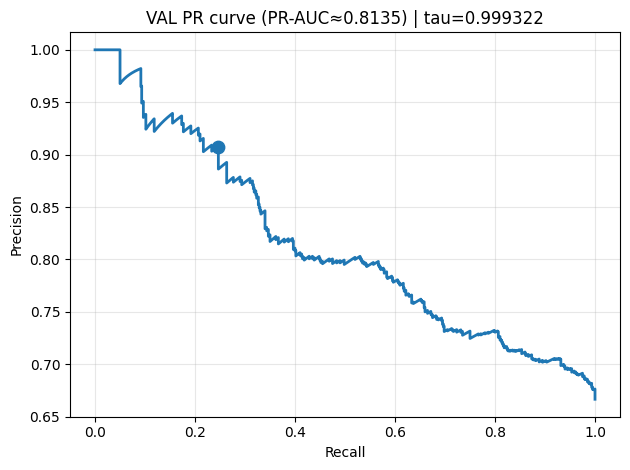

[VAL] PR curve saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/plots/VAL_PR_curve_with_tau_topk.png
[VAL] PR-AUC≈ 0.8135285454587735
[VAL] point@tau -> P/R: 0.9074074074074019 0.24499999999999958


In [22]:
# =============================================================================
# Validation PR curve with selected threshold
# =============================================================================

pr_info = save_val_pr_curve_with_tau(
    y_true=y_true_val,
    y_score=y_score_val,
    tau=TAU_AREA,
    out_path=DIR_PLOTS / "VAL_PR_curve_with_tau_topk.png",
)

print("[VAL] PR curve saved:", DIR_PLOTS / "VAL_PR_curve_with_tau_topk.png")
print("[VAL] PR-AUC≈", pr_info["pr_auc"])
print("[VAL] point@tau -> P/R:", pr_info["p_tau"], pr_info["r_tau"])

In [23]:
# =============================================================================
# Test inference
# =============================================================================

test_res = infer_stitch_save_and_cm(
    runner=runner,
    dl=dl_test,
    ds=ds_test,
    device=DEVICE,
    thr_pix=THR,
    tau_area=TAU_AREA,
    topk_frac=TOPK_FRAC,
    topk_min_k=TOPK_MIN_K,
    pred_masks_dir=DIR_MASKS,
    save_masks=True,
)

print("Saved masks in:", DIR_MASKS)

Infer+stitch: 100%|███████████████████████████████████████████████████████████████████| 890/890 [24:42<00:00,  1.67s/it]

Saved masks in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/pred_masks


In [24]:
# =============================================================================
# Test confusion matrices and ROC/PR curves
# =============================================================================

pix_cm_all = test_res["pix_cm"]["all"]
img_any_all = test_res["img_cm_any"]["all"]
img_area_all = test_res["img_cm_area"]["all"]

save_cm_png(cm_to_array(pix_cm_all), "PIXEL CM (ALL)", DIR_CMS / "cm_pixel_all.png")
save_cm_png(cm_to_array(img_any_all), "IMG CM any-pixel", DIR_CMS / "cm_img_any_all.png")
save_cm_png(cm_to_array(img_area_all), f"IMG CM area (tau={TAU_AREA:.6g})", DIR_CMS / "cm_img_area_all.png")

for split in ["tamp", "good"]:
    save_cm_png(
        cm_to_array(test_res["pix_cm"][split]),
        f"PIXEL CM ({split})",
        DIR_CMS / f"cm_pixel_{split}.png",
    )

    save_cm_png(
        cm_to_array(test_res["img_cm_any"][split]),
        f"IMG CM any ({split})",
        DIR_CMS / f"cm_img_any_{split}.png",
    )

    save_cm_png(
        cm_to_array(test_res["img_cm_area"][split]),
        f"IMG CM area ({split}) tau={TAU_AREA:.6g}",
        DIR_CMS / f"cm_img_area_{split}.png",
    )

print("Saved CMs in:", DIR_CMS)

y_score_test = test_res["img_scores"]
y_true_test = test_res["img_labels"]

test_auc = save_roc_pr_curves(
    y_true_test,
    y_score_test,
    DIR_PLOTS,
    prefix="TEST_image_area",
)

print("TEST AUCs:", test_auc)
print("Saved plots in:", DIR_PLOTS)

Saved CMs in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/confusion_matrices
TEST AUCs: {'roc_auc': 0.7035333333333333, 'pr_auc': 0.8192861697918994, 'recall@fpr=1%': 0.0, 'recall@fpr=5%': 0.20833333333333334, 'recall@fpr=10%': 0.3233333333333333}
Saved plots in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/plots


In [25]:
# =============================================================================
# Pixel-level metrics table
# =============================================================================

splits_pixel = ["tamp", "all"]

rows_pix = []
for split in splits_pixel:
    cm = test_res["pix_cm"][split]
    iou, precision, recall, f1, acc = pix_metrics(cm)

    rows_pix.append(
        {
            "split": split,
            "thr_pix": float(THR),
            "IoU": float(iou),
            "Precision": float(precision),
            "Recall": float(recall),
            "F1": float(f1),
            "Acc": float(acc),
            "TP": int(cm["tp"]),
            "FP": int(cm["fp"]),
            "FN": int(cm["fn"]),
            "TN": int(cm["tn"]),
        }
    )

df_pix = pd.DataFrame(rows_pix)
df_pix["split"] = pd.Categorical(df_pix["split"], categories=splits_pixel, ordered=True)
df_pix = df_pix.sort_values("split").reset_index(drop=True)

path_pix = DIR_TABLE / "metrics_pixel.csv"
df_pix.to_csv(path_pix, index=False)

print("Saved:", path_pix)
df_pix

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/tables/metrics_pixel.csv


,split,thr_pix,IoU,Precision,Recall,F1,Acc,TP,FP,FN,TN
0,tamp,0.015143,0.118302,0.194364,0.232129,0.211574,0.979618,2158488,8946918,7140174,771017894
1,all,0.015143,0.106143,0.163578,0.232129,0.191916,0.985928,2158488,11036999,7140174,1271399998


In [26]:
# =============================================================================
# Image-level metrics using any-pixel rule
# =============================================================================

splits_any = ["tamp", "all"]

rows_any = []
for split in splits_any:
    cm = test_res["img_cm_any"][split]
    precision, recall, f1, acc, fpr, specificity = img_metrics(cm)

    rows_any.append(
        {
            "split": split,
            "thr_pix": float(THR),
            "rule": "any_pixel>=thr_pix",
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Acc": acc,
            "FPR": fpr,
            "Specificity": specificity,
            "TP": int(cm["tp"]),
            "FP": int(cm["fp"]),
            "FN": int(cm["fn"]),
            "TN": int(cm["tn"]),
        }
    )

df_any = pd.DataFrame(rows_any)

path_any = DIR_TABLE / "metrics_image_any.csv"
df_any.to_csv(path_any, index=False)

print("Saved:", path_any)
df_any

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/tables/metrics_image_any.csv


,split,thr_pix,rule,Precision,Recall,F1,Acc,FPR,Specificity,TP,FP,FN,TN
0,tamp,0.015143,any_pixel>=thr_pix,1.00000,0.81,0.895028,0.810000,0.0,0.0,486,0,114,0
1,all,0.015143,any_pixel>=thr_pix,0.72973,0.81,0.767773,0.673333,0.6,0.4,486,180,114,120


In [27]:
# =============================================================================
# Image-level metrics using TOP-K rule
# =============================================================================

splits_topk = ["tamp", "all"]

rows_topk = []
for split in splits_topk:
    cm = test_res["img_cm_area"][split]
    precision, recall, f1, acc, fpr, specificity = img_metrics(cm)

    rows_topk.append(
        {
            "split": split,
            "thr_pix": float(THR),
            "tau_topk": float(TAU_AREA),
            "topk_frac": float(TOPK_FRAC),
            "topk_min_k": int(TOPK_MIN_K),
            "rule": "topk_mean(prob)>=tau_topk",
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Acc": acc,
            "FPR": fpr,
            "Specificity": specificity,
            "TP": int(cm["tp"]),
            "FP": int(cm["fp"]),
            "FN": int(cm["fn"]),
            "TN": int(cm["tn"]),
        }
    )

df_topk = pd.DataFrame(rows_topk)

path_topk = DIR_TABLE / "metrics_image_topk.csv"
df_topk.to_csv(path_topk, index=False)

print("Saved:", path_topk)
df_topk

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/tables/metrics_image_topk.csv


,split,thr_pix,tau_topk,topk_frac,topk_min_k,rule,Precision,Recall,F1,Acc,FPR,Specificity,TP,FP,FN,TN
0,tamp,0.015143,0.999322,0.002,5,topk_mean(prob)>=tau_topk,1.000000,0.258333,0.410596,0.258333,0.000000,0.000000,155,0,445,0
1,all,0.015143,0.999322,0.002,5,topk_mean(prob)>=tau_topk,0.875706,0.258333,0.398970,0.481111,0.073333,0.926667,155,22,445,278


In [28]:
# =============================================================================
# Good-only metrics
# =============================================================================

cm_good_any = test_res["img_cm_any"]["good"]
cm_good_topk = test_res["img_cm_area"]["good"]

_, _, _, acc_any, fpr_any, spec_any = img_metrics(cm_good_any)
_, _, _, acc_topk, fpr_topk, spec_topk = img_metrics(cm_good_topk)

df_good = pd.DataFrame(
    [
        {
            "rule": "any_pixel>=thr_pix",
            "thr_pix": float(THR),
            "tau_topk": np.nan,
            "topk_frac": np.nan,
            "topk_min_k": np.nan,
            "Acc_good": float(acc_any),
            "FPR_good": float(fpr_any),
            "Specificity_good": float(spec_any),
            "FP_good": int(cm_good_any["fp"]),
            "TN_good": int(cm_good_any["tn"]),
            "N_good": int(cm_good_any["fp"] + cm_good_any["tn"]),
        },
        {
            "rule": "topk_mean(prob)>=tau_topk",
            "thr_pix": float(THR),
            "tau_topk": float(TAU_AREA),
            "topk_frac": float(TOPK_FRAC),
            "topk_min_k": int(TOPK_MIN_K),
            "Acc_good": float(acc_topk),
            "FPR_good": float(fpr_topk),
            "Specificity_good": float(spec_topk),
            "FP_good": int(cm_good_topk["fp"]),
            "TN_good": int(cm_good_topk["tn"]),
            "N_good": int(cm_good_topk["fp"] + cm_good_topk["tn"]),
        },
    ]
)

path_good = DIR_TABLE / "metrics_good_only.csv"
df_good.to_csv(path_good, index=False)

print("Saved:", path_good)
df_good

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/tables/metrics_good_only.csv


,rule,thr_pix,tau_topk,topk_frac,topk_min_k,Acc_good,FPR_good,Specificity_good,FP_good,TN_good,N_good
0,any_pixel>=thr_pix,0.015143,NaN,NaN,NaN,0.400000,0.600000,0.400000,180,120,300
1,topk_mean(prob)>=tau_topk,0.015143,0.999322,0.002,5.0,0.926667,0.073333,0.926667,22,278,300


In [29]:
# =============================================================================
# Good-only summary
# =============================================================================

cm_good = test_res["img_cm_area"]["good"]
_, _, _, acc_g, fpr_g, spec_g = img_metrics(cm_good)

print(
    f"[TEST][good] "
    f"Acc={acc_g:.4f} "
    f"FPR_good={fpr_g:.4f} "
    f"Specificity_good={spec_g:.4f} "
    f"FP={cm_good['fp']} "
    f"TN={cm_good['tn']}"
)

[TEST][good] Acc=0.9267 FPR_good=0.0733 Specificity_good=0.9267 FP=22 TN=278


In [30]:
# =============================================================================
# Test AUC table
# =============================================================================

df_auc = pd.DataFrame(
    [
        {
            "topk_frac": float(TOPK_FRAC),
            "topk_min_k": int(TOPK_MIN_K),
            "tau_topk": float(TAU_AREA),
            "ROC_AUC": float(test_auc["roc_auc"]),
            "PR_AUC": float(test_auc["pr_auc"]),
            "Recall@FPR=1%": float(test_auc["recall@fpr=1%"]),
            "Recall@FPR=5%": float(test_auc["recall@fpr=5%"]),
            "Recall@FPR=10%": float(test_auc["recall@fpr=10%"]),
        }
    ]
)

path_auc = DIR_TABLE / "metrics_auc_test.csv"
df_auc.to_csv(path_auc, index=False)

print("Saved:", path_auc)
df_auc

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/50 epochs/segformer_b2_rgb_ela_rtm/tables/metrics_auc_test.csv


,topk_frac,topk_min_k,tau_topk,ROC_AUC,PR_AUC,Recall@FPR=1%,Recall@FPR=5%,Recall@FPR=10%
0,0.002,5,0.999322,0.703533,0.819286,0.0,0.208333,0.323333


In [41]:
# =============================================================================
# Load TensorBoard scalar events
# =============================================================================

event_files = sorted(glob.glob(str(RUN_DIR / "**" / "events.out.tfevents.*"), recursive=True))
print("event files:", len(event_files))

rows = []
for event_file in event_files:
    ea = event_accumulator.EventAccumulator(event_file)
    ea.Reload()

    for tag in ea.Tags().get("scalars", []):
        for event in ea.Scalars(tag):
            rows.append(
                {
                    "file": event_file,
                    "tag": tag,
                    "step": event.step,
                    "value": event.value,
                }
            )

df_all = pd.DataFrame(rows)

print("rows:", len(df_all))
print("unique tags:", df_all["tag"].nunique())

df_all.head()

event files: 12
rows: 31404
unique tags: 22


,file,tag,step,value
0,/home/guests3/rma/tese/codigo_tese/detect_forg...,Running Training Loss,3486,1.398058
1,/home/guests3/rma/tese/codigo_tese/detect_forg...,Running Training Loss,3488,1.795046
2,/home/guests3/rma/tese/codigo_tese/detect_forg...,Running Training Loss,3489,1.715578
3,/home/guests3/rma/tese/codigo_tese/detect_forg...,Running Training Loss,3491,1.902209
4,/home/guests3/rma/tese/codigo_tese/detect_forg...,Running Training Loss,3493,1.956779


In [42]:
# =============================================================================
# Inspect TensorBoard tags
# =============================================================================

tag_counts = df_all.groupby("tag")["step"].nunique().sort_values(ascending=False)
tag_counts.head(60)

tag
Running Training Loss           24969
Epoch Duration                     71
Validation_BAL Loss                71
Validation_BAL BestThreshold       71
Validation_BAL BestF1              71
Validation f1@0.5                  71
Validation UseThr                  71
Validation Recall@UseThr           71
Validation Precision@UseThr        71
Validation Loss                    71
Validation F1@UseThr               71
Validation BestThreshold           71
Validation BestF1                  71
Training recall                    71
Training precision                 71
Training f1-score                  71
Training UseThr                    71
Training Recall@UseThr             71
Training Precision@UseThr          71
Training Loss                      71
Training F1@UseThr                 71
Validation_BAL f1@0.5              71
Name: step, dtype: int64

In [43]:
# =============================================================================
# Map TensorBoard steps to epochs
# =============================================================================

def pick_anchor_tag(tag_counts, prefer=None, min_points: int = 5):
    """Pick the scalar tag used as reference for epoch indexing."""
    
    if prefer is None:
        prefer = [
            "Validation Loss",
            "Validation f1@0.5",
            "Validation f1@bestThr",
            "Validation BestF1",
            "Training Loss",
            "Training f1-score",
        ]

    for tag in prefer:
        if tag in tag_counts.index and tag_counts[tag] >= min_points:
            return tag

    candidates = tag_counts[tag_counts >= min_points]

    if len(candidates) == 0:
        return tag_counts.index[0]

    return candidates.index[0]


anchor_tag = pick_anchor_tag(tag_counts, min_points=5)
anchor_steps = sorted(df_all[df_all["tag"] == anchor_tag]["step"].unique())

print("Anchor tag:", anchor_tag)
print("Num anchor steps:", len(anchor_steps))
print("First steps:", anchor_steps[:10])

step_to_epoch = {step: epoch for epoch, step in enumerate(anchor_steps)}

df_all["epoch"] = df_all["step"].map(step_to_epoch)
df_epochs = df_all.dropna(subset=["epoch"]).copy()
df_epochs["epoch"] = df_epochs["epoch"].astype(int) + EPOCH_OFFSET

# ============================================================
# Filter epoch range
# ============================================================

if EPOCH_MIN is not None:
    df_epochs = df_epochs[df_epochs["epoch"] >= EPOCH_MIN].copy()

if EPOCH_MAX is not None:
    df_epochs = df_epochs[df_epochs["epoch"] < EPOCH_MAX].copy()

print("rows with epoch:", len(df_epochs))
print("epoch range:", df_epochs["epoch"].min(), "to", df_epochs["epoch"].max())
df_epochs.head()

Anchor tag: Validation Loss
Num anchor steps: 71
First steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rows with epoch: 1071
epoch range: 0 to 49


,file,tag,step,value,epoch
10000,/home/guests3/rma/tese/codigo_tese/detect_forg...,Training UseThr,6,0.450000,6
10001,/home/guests3/rma/tese/codigo_tese/detect_forg...,Training UseThr,7,0.100000,7
10002,/home/guests3/rma/tese/codigo_tese/detect_forg...,Training UseThr,8,0.045449,8
10003,/home/guests3/rma/tese/codigo_tese/detect_forg...,Training UseThr,9,0.015143,9
10004,/home/guests3/rma/tese/codigo_tese/detect_forg...,Training UseThr,10,0.350000,10


In [44]:
# =============================================================================
# Available metrics per epoch
# =============================================================================

epoch_tag_counts = df_epochs.groupby("tag")["epoch"].nunique().sort_values(ascending=False)
epoch_tag_counts.head(60)

tag
Epoch Duration                  50
Validation F1@UseThr            50
Validation_BAL Loss             50
Validation_BAL BestThreshold    50
Validation_BAL BestF1           50
Validation f1@0.5               50
Validation UseThr               50
Validation Recall@UseThr        50
Validation Precision@UseThr     50
Validation Loss                 50
Validation BestThreshold        50
Validation BestF1               50
Training recall                 50
Training precision              50
Training f1-score               50
Training UseThr                 50
Training Recall@UseThr          50
Training Precision@UseThr       50
Training Loss                   50
Training F1@UseThr              50
Validation_BAL f1@0.5           50
Running Training Loss           12
Name: epoch, dtype: int64

available: ['Training Loss', 'Training precision', 'Training recall', 'Training f1-score', 'Validation Loss', 'Validation f1@0.5', 'Validation BestF1']


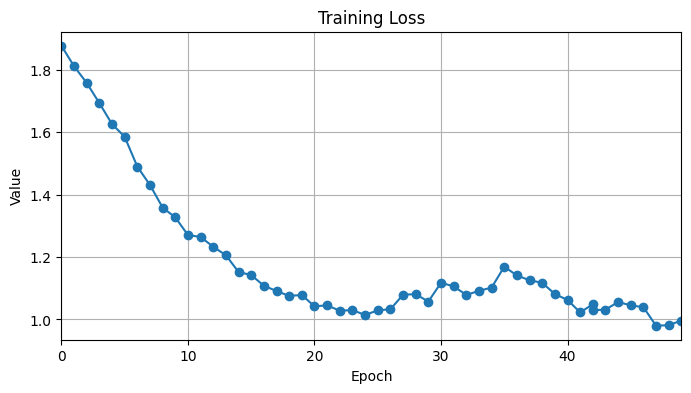

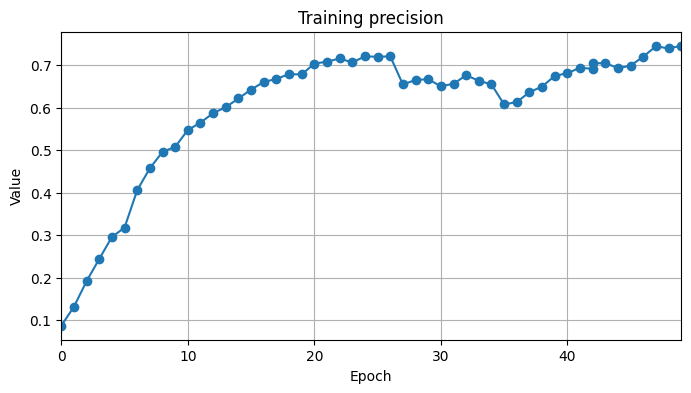

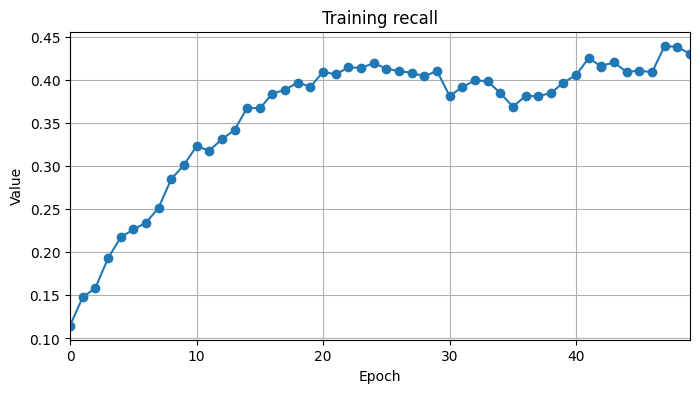

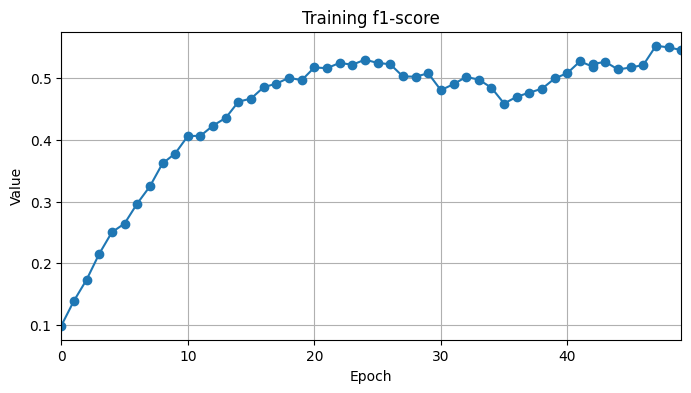

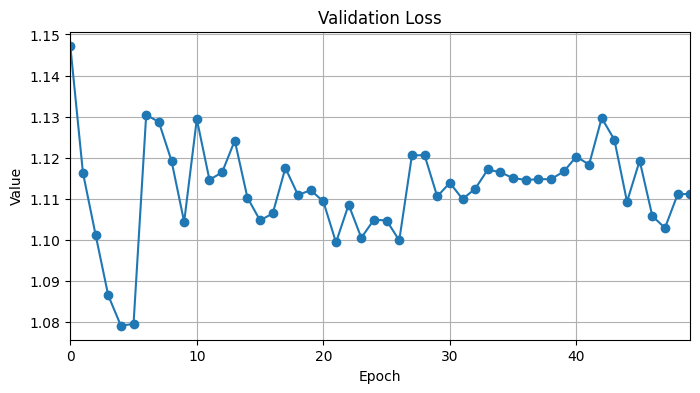

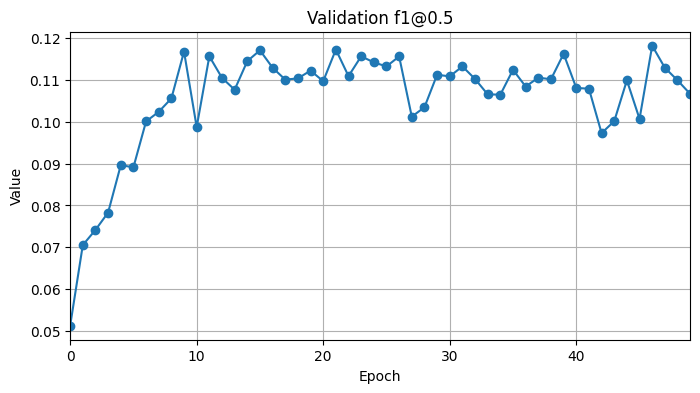

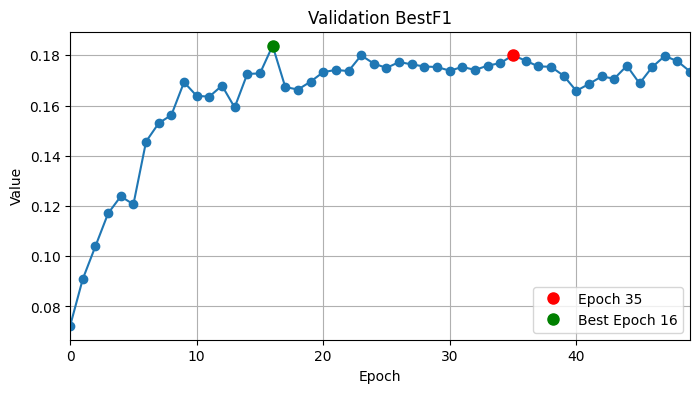

In [45]:
# =============================================================================
# Plot selected training metrics
# =============================================================================

metrics_of_interest = [
    "Training Loss",
    "Training precision",
    "Training recall",
    "Training f1-score",
    "Validation Loss",
    "Validation f1@0.5",
    "Validation f1@bestThr",
    "Validation BestF1",
]

available = [tag for tag in metrics_of_interest if tag in df_epochs["tag"].unique()]

print("available:", available)

for tag in available:
    metric_df = df_epochs[df_epochs["tag"] == tag].sort_values("epoch")

    plt.figure(figsize=(8, 4))
    plt.plot(metric_df["epoch"], metric_df["value"], marker="o")

    # the training code saves the best checkpoint using Validation BestF1 (Best pixel-level segmentation F1)
    # therefore, only this plot receives the fixed-epoch and best-epoch highlights
    if tag == "Validation BestF1":

        # fixed epoch highlight (red)
        highlight_epoch = 35
        point = metric_df[metric_df["epoch"] == highlight_epoch]

        if not point.empty:
            highlight_value = point["value"].iloc[0]

            plt.plot(
                highlight_epoch,
                highlight_value,
                marker="o",
                color="red",
                markersize=8,
                linestyle="None",
                label=f"Epoch {highlight_epoch}",
                zorder=5,
            )

        # best value in the plot (green highlight)
        best_idx = metric_df["value"].idxmax()

        best_epoch = metric_df.loc[best_idx, "epoch"]
        best_value = metric_df.loc[best_idx, "value"]

        plt.plot(
            best_epoch,
            best_value,
            marker="o",
            color="green",
            markersize=8,
            linestyle="None",
            label=f"Best Epoch {best_epoch}",
            zorder=6,
        )

        plt.legend()

    plt.title(tag)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.grid(True)

    if EPOCH_MIN is not None or EPOCH_MAX is not None:
        plt.xlim(
            left=EPOCH_MIN if EPOCH_MIN is not None else df_epochs["epoch"].min(),
            right=(EPOCH_MAX - 1) if EPOCH_MAX is not None else df_epochs["epoch"].max(),
        )
        
    plt.show()

In [46]:
# =============================================================================
# Save training plots and metrics table
# =============================================================================

OUT_DIR = (
    PROJECT_ROOT1
    / "models"
    / "eval_outputs_corretoo"
    / EXP_NAME_TRAIN
)  # change
OUT_DIR.mkdir(parents=True, exist_ok=True)

for tag in available:
    metric_df = df_epochs[df_epochs["tag"] == tag].sort_values("epoch")

    plt.figure(figsize=(8, 4))
    plt.plot(metric_df["epoch"], metric_df["value"], marker="o")

    # the training code saves the best checkpoint using Validation BestF1 (Best pixel-level segmentation F1)
    # therefore, only this plot receives the fixed-epoch and best-epoch highlights
    if tag == "Validation BestF1":
        # fixed epoch highlight (red)
        highlight_epoch = 35
        point = metric_df[metric_df["epoch"] == highlight_epoch]
    
        if not point.empty:
            highlight_value = point["value"].iloc[0]
    
            plt.plot(
                highlight_epoch,
                highlight_value,
                marker="o",
                color="red",
                markersize=8,
                linestyle="None",
                label=f"Epoch {highlight_epoch}",
                zorder=5,
            )
    
        # best value in the plot (green highlight)
        best_idx = metric_df["value"].idxmax()
    
        best_epoch = metric_df.loc[best_idx, "epoch"]
        best_value = metric_df.loc[best_idx, "value"]
    
        plt.plot(
            best_epoch,
            best_value,
            marker="o",
            color="green",
            markersize=8,
            linestyle="None",
            label=f"Best Epoch {best_epoch}",
            zorder=6,
        )
    
        plt.legend()

    plt.title(tag)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.grid(True)

    if EPOCH_MIN is not None or EPOCH_MAX is not None:
        plt.xlim(
            left=EPOCH_MIN if EPOCH_MIN is not None else df_epochs["epoch"].min(),
            right=(EPOCH_MAX - 1) if EPOCH_MAX is not None else df_epochs["epoch"].max(),
        )

    safe_name = tag.replace(" ", "_").replace("/", "_").replace("@", "at")
    plt.savefig(OUT_DIR / f"{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.close()

summary = (
    df_epochs
    .pivot_table(index="epoch", columns="tag", values="value", aggfunc="last")
    .sort_index()
)

summary_path = (
    PROJECT_ROOT1
    / "models"
    / "eval_outputs_corretoo"
    / "TRAIN/All epochs/segformer_b2_rgb_ela_rtm"
    / "training_metrics_per_epoch.csv"    # change
)
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(summary_path)

print("Saved plots to:", OUT_DIR)
print("Saved CSV to:", summary_path)

summary.head()

Saved plots to: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/TRAIN/All epochs/segformer_b2_rgb_ela_rtm/training_metric_plots
Saved CSV to: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/TRAIN/All epochs/segformer_b2_rgb_ela_rtm/training_metrics_per_epoch.csv


tag,Epoch Duration,Running Training Loss,Training F1@UseThr,Training Loss,Training Precision@UseThr,Training Recall@UseThr,Training UseThr,Training f1-score,Training precision,Training recall,...,Validation F1@UseThr,Validation Loss,Validation Precision@UseThr,Validation Recall@UseThr,Validation UseThr,Validation f1@0.5,Validation_BAL BestF1,Validation_BAL BestThreshold,Validation_BAL Loss,Validation_BAL f1@0.5
epoch,,,,,,,,,,,,,,,,,,,,,
0,2940.120361,NaN,0.086385,1.877497,0.071062,0.110133,0.500000,0.098926,0.086956,0.114718,...,0.067425,1.147268,0.045133,0.133226,0.500000,0.051239,0.108068,0.600000,1.877636,0.112978
1,3502.537598,NaN,0.118637,1.811761,0.185733,0.087153,0.800000,0.139241,0.131619,0.147801,...,0.086296,1.116366,0.092047,0.081222,0.800000,0.070524,0.132287,0.200000,1.815761,0.142400
2,2906.136475,NaN,0.171897,1.758296,0.204687,0.148163,0.400000,0.173531,0.191937,0.158347,...,0.103993,1.101260,0.098056,0.110696,0.400000,0.074144,0.134794,0.051510,1.805544,0.138258
3,2804.201660,2.194798,0.203834,1.693580,0.270318,0.163598,0.450000,0.215483,0.244050,0.192902,...,0.111501,1.086494,0.145321,0.090451,0.450000,0.078301,0.158203,0.021204,1.792746,0.148455
4,3147.675537,NaN,0.237963,1.626264,0.236630,0.239311,0.065653,0.250503,0.295896,0.217185,...,0.119515,1.079112,0.095555,0.159511,0.065653,0.089620,0.157299,0.075755,1.765598,0.170345
